# 02 Graph Analysis of POIs using GraphFrames

This notebook extends the raw +Tour dataset loading workflow into graph-based smart tourism analysis.

Main tasks covered in this notebook:

1. Build GraphFrames from POI and travel-distance data.
2. Run PageRank for each POI network.
3. Calculate POI popularity from tourist visit records.
4. Compare PageRank with visit-based POI popularity.
5. Use BFS and ShortestPaths to analyze connectivity between POIs.
6. Use a weighted shortest path method based on the distance matrix.
7. Plot and save figures for the analysis report.

> Note: GraphFrames `BFS` and `shortestPaths` are unweighted graph algorithms. They measure the number of edges, not the actual travel distance. For the true shortest route by distance, this notebook also includes a weighted shortest path implementation using NetworkX.

## 1. Configure Python path for PySpark

This section ensures that PySpark uses the same Python interpreter as the current notebook kernel.

In [1]:
import os
import sys
from pathlib import Path

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

print("Python executable:")
print(sys.executable)

Python executable:
/home/cnkdy/projects/smart-tourism/.venv/bin/python


## 2. Start Spark with GraphFrames support

GraphFrames requires a Spark package. The package below is configured for Spark 4 and Scala 2.13.

If the import of `GraphFrame` fails, install the Python wrapper with:

```python
%pip install graphframes-py
```

Then restart the notebook kernel and run all cells again.

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def create_spark_session(app_name="PlusTourGraphAnalysis"):
    spark = (
        SparkSession.builder
        .appName(app_name)
        .master("local[*]")
        .config("spark.hadoop.fs.defaultFS", "file:///")
        .config("spark.jars.repositories", "https://repos.spark-packages.org/")
        .config("spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.9.3")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("ERROR")
    return spark

spark = create_spark_session("PlusTourGraphAnalysis")

print("Spark version:", spark.version)

https://repos.spark-packages.org/ added as a remote repository with the name: repo-1
:: loading settings :: url = jar:file:/home/cnkdy/projects/smart-tourism/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/cnkdy/.ivy2.5.2/cache
The jars for the packages stored in: /home/cnkdy/.ivy2.5.2/jars
io.graphframes#graphframes-spark4_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-e74bfb9a-20ef-46b8-96e3-ac477728279d;1.0
	confs: [default]
	found io.graphframes#graphframes-spark4_2.13;0.9.3 in central
:: resolution report :: resolve 372ms :: artifacts dl 10ms
	:: modules in use:
	io.graphframes#graphframes-spark4_2.13;0.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	--

Spark version: 4.1.2


In [3]:
try:
    from graphframes import GraphFrame
    print("GraphFrames imported successfully.")
except Exception as e:
    print("GraphFrames import failed.")
    print("Error:", e)
    print("Try running: %pip install graphframes-py")
    raise

GraphFrames imported successfully.


## 3. Define project folders

The notebook assumes the following project structure:

```text
smart-tourism/
├─ Datasets/
│  └─ Raw/
├─ notebooks/
├─ Analysis/
│  ├─ figures/
│  └─ outputs/
└─ src/
```

The output figures and CSV files will be saved under the `Analysis` folder.

In [4]:
current_path = Path.cwd()

if current_path.name.lower() == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

raw_data_path = project_root / "Datasets" / "Raw"
analysis_path = project_root / "Analysis"
figure_dir = analysis_path / "figures"
output_dir = analysis_path / "outputs"

figure_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Raw data path:", raw_data_path)
print("Raw data folder exists:", raw_data_path.exists())
print("Figure output folder:", figure_dir)
print("Table output folder:", output_dir)

Project root: /home/cnkdy/projects/smart-tourism
Raw data path: /home/cnkdy/projects/smart-tourism/Datasets/Raw
Raw data folder exists: True
Figure output folder: /home/cnkdy/projects/smart-tourism/Analysis/figures
Table output folder: /home/cnkdy/projects/smart-tourism/Analysis/outputs


## 4. Discover raw dataset files

The raw dataset folder is scanned recursively. The notebook expects to find:

- `touristsVisits.csv`
- `POIs.csv`
- Distance matrix files in JSON format

The city name is extracted from the parent folder name.

In [5]:
if not raw_data_path.exists():
    raise FileNotFoundError(f"Raw data folder not found: {raw_data_path}")

all_files = [p for p in raw_data_path.rglob("*") if p.is_file()]

csv_files = [p for p in all_files if p.suffix.lower() == ".csv"]
json_files = [p for p in all_files if p.suffix.lower() == ".json"]

print("Number of CSV files:", len(csv_files))
print("Number of JSON files:", len(json_files))

print("\nSample CSV files:")
for p in csv_files[:10]:
    print("-", p.relative_to(project_root))

print("\nSample JSON files:")
for p in json_files[:10]:
    print("-", p.relative_to(project_root))

Number of CSV files: 26
Number of JSON files: 13

Sample CSV files:
- Datasets/Raw/Madrid/touristsVisits.csv
- Datasets/Raw/Madrid/POIs.csv
- Datasets/Raw/Perth/touristsVisits.csv
- Datasets/Raw/Perth/POIs.csv
- Datasets/Raw/Edinburgh/touristsVisits.csv
- Datasets/Raw/Edinburgh/POIs.csv
- Datasets/Raw/Osaka/touristsVisits.csv
- Datasets/Raw/Osaka/POIs.csv
- Datasets/Raw/Barcelona/touristsVisits.csv
- Datasets/Raw/Barcelona/POIs.csv

Sample JSON files:
- Datasets/Raw/Madrid/distanceMatrix.json
- Datasets/Raw/Perth/distanceMatrix.json
- Datasets/Raw/Edinburgh/distanceMatrix.json
- Datasets/Raw/Osaka/distanceMatrix.json
- Datasets/Raw/Barcelona/distanceMatrix.json
- Datasets/Raw/London/distanceMatrix.json
- Datasets/Raw/Melbourne/distanceMatrix.json
- Datasets/Raw/Toronto/distanceMatrix.json
- Datasets/Raw/NewDelhi/distanceMatrix.json
- Datasets/Raw/Athens/distanceMatrix.json


## 5. Load tourist visits

The tourist visit table is used to calculate POI popularity. Popularity is measured by the number of visit records for each POI.

In [6]:
visit_files = [p for p in csv_files if p.name.lower() == "touristsvisits.csv"]

print("Tourist visit files found:", len(visit_files))

visit_dfs = []

for file in visit_files:
    city = file.parent.name
    temp_df = (
        spark.read
        .option("header", True)
        .option("inferSchema", True)
        .csv(str(file))
        .withColumn("city", F.lit(city))
    )
    visit_dfs.append(temp_df)

if len(visit_dfs) == 0:
    raise FileNotFoundError("No touristsVisits.csv files were found under Datasets/Raw.")

visit_df = visit_dfs[0]

for df in visit_dfs[1:]:
    visit_df = visit_df.unionByName(df, allowMissingColumns=True)

print("Visit rows:", visit_df.count())
visit_df.printSchema()
visit_df.show(10, truncate=False)

Tourist visit files found: 13


Visit rows: 265554
root
 |-- photoID: long (nullable = true)
 |-- userID: string (nullable = true)
 |-- dateTaken: long (nullable = true)
 |-- poiID: integer (nullable = true)
 |-- poiTheme: string (nullable = true)
 |-- seqID: integer (nullable = true)
 |-- city: string (nullable = false)

+-------+------------+----------+-----+----------+-----+------+
|photoID|userID      |dateTaken |poiID|poiTheme  |seqID|city  |
+-------+------------+----------+-----+----------+-----+------+
|1      |10006319@N00|1501337163|6    |Museum    |7    |Madrid|
|2      |10006319@N00|1501337709|6    |Museum    |7    |Madrid|
|3      |10006319@N00|1501338991|6    |Museum    |7    |Madrid|
|4      |10006319@N00|1512573475|15   |Museum    |10   |Madrid|
|5      |10006319@N00|1512573514|15   |Museum    |10   |Madrid|
|6      |10006319@N00|1512675198|1    |Historical|11   |Madrid|
|7      |10006319@N00|1512675514|1    |Historical|11   |Madrid|
|8      |10006319@N00|1522253652|11   |Museum    |16   |Madrid|
|9  

## 6. Load POI metadata

The POI table provides the list of vertices for the graph. Each POI will become one graph vertex.

In [7]:
poi_files = [p for p in csv_files if p.name.lower() == "pois.csv"]

print("POI files found:", len(poi_files))

poi_dfs = []

for file in poi_files:
    city = file.parent.name
    temp_df = (
        spark.read
        .option("header", True)
        .option("inferSchema", True)
        .csv(str(file))
        .withColumn("city", F.lit(city))
    )
    poi_dfs.append(temp_df)

if len(poi_dfs) == 0:
    raise FileNotFoundError("No POIs.csv files were found under Datasets/Raw.")

poi_df = poi_dfs[0]

for df in poi_dfs[1:]:
    poi_df = poi_df.unionByName(df, allowMissingColumns=True)

print("POI rows:", poi_df.count())
poi_df.printSchema()
poi_df.show(10, truncate=False)

POI files found: 13
POI rows: 444
root
 |-- poiID: integer (nullable = true)
 |-- poiName: string (nullable = true)
 |-- poiLat: double (nullable = true)
 |-- poiLon: double (nullable = true)
 |-- poiTheme: string (nullable = true)
 |-- city: string (nullable = false)

+-----+-----------------------------------------+----------+----------+----------+------+
|poiID|poiName                                  |poiLat    |poiLon    |poiTheme  |city  |
+-----+-----------------------------------------+----------+----------+----------+------+
|1    |Plaza_Mayor                              |40.415511 |-3.7074009|Historical|Madrid|
|2    |El_Retiro_Park                           |40.4152606|-3.6844995|Park      |Madrid|
|3    |San_Miguel_Market                        |40.4154223|-3.709022 |Shopping  |Madrid|
|4    |Museo_Nacional_del_Prado                 |40.4137818|-3.6921271|Museum    |Madrid|
|5    |Royal_Palace_of_Madrid                   |40.417955 |-3.714312 |Palace    |Madrid|
|6    |Mus

## 7. Detect POI ID columns

Different versions of the dataset may use slightly different column names. This helper function tries to detect the POI ID column automatically.

If the detected column is wrong, manually set:

```python
poi_id_col = "your_column_name"
visit_poi_col = "your_column_name"
```

In [8]:
def detect_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    for c in columns:
        c_lower = c.lower()
        if "poi" in c_lower and ("id" in c_lower or c_lower == "poi"):
            return c
    return None

poi_id_candidates = [
    "poiID", "POIId", "poi_id", "id", "POI_id", "poi"
]

visit_poi_candidates = [
    "poiID", "POIId", "poi_id", "poi", "POI", "poiId"
]

poi_id_col = detect_column(poi_df.columns, poi_id_candidates)
visit_poi_col = detect_column(visit_df.columns, visit_poi_candidates)

print("Detected POI ID column in POI table:", poi_id_col)
print("Detected POI ID column in visit table:", visit_poi_col)

if poi_id_col is None:
    raise ValueError(f"Could not detect POI ID column in POI table. Available columns: {poi_df.columns}")

if visit_poi_col is None:
    raise ValueError(f"Could not detect POI ID column in visit table. Available columns: {visit_df.columns}")

Detected POI ID column in POI table: poiID
Detected POI ID column in visit table: poiID


## 8. Create graph vertices

GraphFrames requires a vertex table with a column named `id`.

Each row in `vertices_all` represents one POI in one city.

In [9]:
vertices_all = (
    poi_df
    .withColumn("id", F.col(poi_id_col).cast("string"))
    .select("city", "id", *[c for c in poi_df.columns if c != "city"])
    .dropDuplicates(["city", "id"])
)

print("Total vertices:", vertices_all.count())
vertices_all.show(10, truncate=False)

Total vertices: 444


[Stage 66:===================================================>    (12 + 1) / 13]

+------+---+-----+-----------------------------------------+----------+----------+----------+
|city  |id |poiID|poiName                                  |poiLat    |poiLon    |poiTheme  |
+------+---+-----+-----------------------------------------+----------+----------+----------+
|Athens|1  |1    |Acropolis_of_Athens                      |37.9715323|23.7257492|Historical|
|Athens|10 |10   |Athens_War_Museum                        |37.9753824|23.7453396|Museum    |
|Athens|11 |11   |Temple_of_Hephaestus                     |37.975595 |23.7214521|Historical|
|Athens|12 |12   |Syntagma_(Constitution)_Square           |37.9755433|23.7348515|Historical|
|Athens|13 |13   |Museum_of_Cycladic_Art                   |37.9758931|23.742275 |Museum    |
|Athens|14 |14   |Radisson_Blu_Park_Hotel_Athens           |37.9911023|23.7333065|Park      |
|Athens|15 |15   |Hellenic_Motor_Museum                    |37.9914349|23.7299098|Museum    |
|Athens|16 |16   |Ethniko_Mouseio_Sugkhrones_Tekhnes_(EMST)|

## 9. Load distance matrix files as graph edges

GraphFrames requires an edge table with:

- `src`: source POI
- `dst`: destination POI

The distance matrix is converted into long format:

```text
city | src | dst | distance
```

The `distance` column is kept for weighted shortest path analysis.

In [10]:
import pandas as pd
from pyspark.sql import functions as F

distance_long_list = []

distance_files = [
    p for p in json_files
    if "distance" in p.name.lower() or "dist" in p.name.lower()
]

print("Distance JSON files found:", len(distance_files))

for file in distance_files:
    city = file.parent.name

    print("Reading:", file)

    pdf = pd.read_json(file)

    # Standardize column names just in case
    pdf.columns = [str(c) for c in pdf.columns]

    required_cols = [
        "fromPOIid",
        "fromPOIName",
        "toPOIid",
        "toPOIName",
        "duration",
        "distance"
    ]

    missing_cols = [c for c in required_cols if c not in pdf.columns]

    if len(missing_cols) > 0:
        raise ValueError(f"Missing columns in {file}: {missing_cols}")

    long_pdf = pdf[[
        "fromPOIid",
        "fromPOIName",
        "toPOIid",
        "toPOIName",
        "duration",
        "distance"
    ]].copy()

    long_pdf["city"] = city

    long_pdf = long_pdf.rename(columns={
        "fromPOIid": "src",
        "toPOIid": "dst",
        "fromPOIName": "src_name",
        "toPOIName": "dst_name"
    })

    long_pdf = long_pdf[[
        "city",
        "src",
        "dst",
        "src_name",
        "dst_name",
        "duration",
        "distance"
    ]]

    distance_long_list.append(long_pdf)

if len(distance_long_list) == 0:
    raise FileNotFoundError("No distance JSON files were found.")

distance_long_pdf = pd.concat(distance_long_list, ignore_index=True)

distance_long_df = spark.createDataFrame(distance_long_pdf)

edges_all = (
    distance_long_df
    .withColumn("src", F.col("src").cast("string"))
    .withColumn("dst", F.col("dst").cast("string"))
    .withColumn("duration", F.col("duration").cast("double"))
    .withColumn("distance", F.col("distance").cast("double"))
    .filter(F.col("src").isNotNull())
    .filter(F.col("dst").isNotNull())
    .filter(F.col("distance").isNotNull())
    .filter(F.col("duration").isNotNull())
    .filter(F.col("src") != F.col("dst"))
    .filter(F.col("distance") > 0)
    .select("city", "src", "dst", "src_name", "dst_name", "duration", "distance")
    .dropDuplicates(["city", "src", "dst"])
)

print("Total edges before adding reverse edges:", edges_all.count())
edges_all.show(10, truncate=False)
edges_all.printSchema()

Distance JSON files found: 13
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/Madrid/distanceMatrix.json
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/Perth/distanceMatrix.json
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/Edinburgh/distanceMatrix.json
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/Osaka/distanceMatrix.json
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/Barcelona/distanceMatrix.json
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/London/distanceMatrix.json
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/Melbourne/distanceMatrix.json
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/Toronto/distanceMatrix.json
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/NewDelhi/distanceMatrix.json
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/Athens/distanceMatrix.json
Reading: /home/cnkdy/projects/smart-tourism/Datasets/Raw/Glasgow/distanceMatrix.json
Reading: /home/cnkdy/projects/smart

Total edges before adding reverse edges: 15290


[Stage 75:===================>                                      (2 + 4) / 6]

+------+---+---+-------------------+-----------------------------------------+--------+--------+
|city  |src|dst|src_name           |dst_name                                 |duration|distance|
+------+---+---+-------------------+-----------------------------------------+--------+--------+
|Athens|1  |10 |Acropolis_of_Athens|Athens_War_Museum                        |1885.0  |2390.0  |
|Athens|1  |11 |Acropolis_of_Athens|Temple_of_Hephaestus                     |761.0   |1097.0  |
|Athens|1  |12 |Acropolis_of_Athens|Syntagma_(Constitution)_Square           |1089.0  |1336.0  |
|Athens|1  |13 |Acropolis_of_Athens|Museum_of_Cycladic_Art                   |1734.0  |2158.0  |
|Athens|1  |14 |Acropolis_of_Athens|Radisson_Blu_Park_Hotel_Athens           |2144.0  |2728.0  |
|Athens|1  |15 |Acropolis_of_Athens|Hellenic_Motor_Museum                    |2019.0  |2597.0  |
|Athens|1  |16 |Acropolis_of_Athens|Ethniko_Mouseio_Sugkhrones_Tekhnes_(EMST)|1028.0  |1360.0  |
|Athens|1  |17 |Acropolis_of_A

## 10. Add reverse edges

Most travel distance matrices represent bidirectional movement between POIs. Therefore, reverse edges are added to make the graph more suitable for tourism route analysis.

In [11]:
edges_reverse = (
    edges_all
    .select(
        "city",
        F.col("dst").alias("src"),
        F.col("src").alias("dst"),
        F.col("dst_name").alias("src_name"),
        F.col("src_name").alias("dst_name"),
        "duration",
        "distance"
    )
)

edges_all = (
    edges_all
    .unionByName(edges_reverse)
    .dropDuplicates(["city", "src", "dst"])
)

print("Total edges after adding reverse edges:", edges_all.count())
edges_all.show(10, truncate=False)

Total edges after adding reverse edges: 15290


[Stage 92:>                                                         (0 + 2) / 2]

+------+---+---+-------------------+-----------------------------------+--------+--------+
|city  |src|dst|src_name           |dst_name                           |duration|distance|
+------+---+---+-------------------+-----------------------------------+--------+--------+
|Athens|1  |11 |Acropolis_of_Athens|Temple_of_Hephaestus               |761.0   |1097.0  |
|Athens|1  |12 |Acropolis_of_Athens|Syntagma_(Constitution)_Square     |1089.0  |1336.0  |
|Athens|1  |15 |Acropolis_of_Athens|Hellenic_Motor_Museum              |2019.0  |2597.0  |
|Athens|1  |17 |Acropolis_of_Athens|Numismatic_Museum_of_Athens        |1236.0  |1524.0  |
|Athens|1  |18 |Acropolis_of_Athens|National_Historical_Museum         |1135.0  |1424.0  |
|Athens|1  |19 |Acropolis_of_Athens|Museum_of_Illusions_Athens_-_Greece|821.0   |1091.0  |
|Athens|1  |20 |Acropolis_of_Athens|Old_Parliament                     |1164.0  |1464.0  |
|Athens|1  |22 |Acropolis_of_Athens|The_Jewish_Museum_of_Greece        |727.0   |862.0   |

## 11. Build one GraphFrame per city

Each city is analyzed as a separate tourism graph.

This prevents POIs from different cities from being connected in the same graph.

In [12]:
cities = [row["city"] for row in vertices_all.select("city").distinct().collect()]
cities = sorted(cities)

graphs = {}

for city in cities:
    v = (
        vertices_all
        .filter(F.col("city") == city)
        .select("id")
        .dropDuplicates()
    )

    e = (
        edges_all
        .filter(F.col("city") == city)
        .select("src", "dst")
        .dropDuplicates()
    )

    graphs[city] = GraphFrame(v, e)

    print(f"{city}: vertices = {v.count()}, edges = {e.count()}")

Athens: vertices = 30, edges = 552
Barcelona: vertices = 30, edges = 812


Budapest: vertices = 39, edges = 1260


Edinburgh: vertices = 29, edges = 600


Glasgow: vertices = 29, edges = 600


London: vertices = 30, edges = 870


...

Melbourne: vertices = 88, edges = 6968


NewDelhi: vertices = 26, edges = 342


Osaka: vertices = 29, edges = 506


Perth: vertices = 25, edges = 342


Toronto: vertices = 30, edges = 812
Vienna: vertices = 29, edges = 756


## 12. Run PageRank for each POI network

PageRank measures the structural importance of each POI in the travel network.

A POI with high PageRank is not necessarily the most visited POI. Instead, it may be a well-connected or strategically important POI in the overall movement network.

In [13]:
pagerank_results = []

for city, g in graphs.items():
    pr = (
        g.pageRank(resetProbability=0.15, maxIter=10)
        .vertices
        .withColumn("city", F.lit(city))
        .select("city", "id", "pagerank")
    )
    pagerank_results.append(pr)

pagerank_df = pagerank_results[0]

for df in pagerank_results[1:]:
    pagerank_df = pagerank_df.unionByName(df)

w_pr = Window.partitionBy("city").orderBy(F.desc("pagerank"))

pagerank_ranked = (
    pagerank_df
    .withColumn("pagerank_rank", F.row_number().over(w_pr))
)

pagerank_ranked.orderBy("city", "pagerank_rank").show(50, truncate=False)

[Stage 4271:=================================================>(2590 + 6) / 2600]]

+---------+---+-------------------+-------------+
|city     |id |pagerank           |pagerank_rank|
+---------+---+-------------------+-------------+
|Athens   |25 |1.2048192771084336 |1            |
|Athens   |15 |1.2048192771084336 |2            |
|Athens   |11 |1.2048192771084336 |3            |
|Athens   |3  |1.2048192771084336 |4            |
|Athens   |8  |1.2048192771084336 |5            |
|Athens   |22 |1.2048192771084336 |6            |
|Athens   |16 |1.2048192771084336 |7            |
|Athens   |24 |1.2048192771084336 |8            |
|Athens   |9  |1.2048192771084336 |9            |
|Athens   |1  |1.2048192771084336 |10           |
|Athens   |20 |1.2048192771084336 |11           |
|Athens   |5  |1.2048192771084336 |12           |
|Athens   |18 |1.2048192771084336 |13           |
|Athens   |10 |1.2048192771084336 |14           |
|Athens   |27 |1.2048192771084336 |15           |
|Athens   |17 |1.2048192771084336 |16           |
|Athens   |4  |1.2048192771084336 |17           |


## 13. Calculate POI popularity

POI popularity is calculated from tourist visit records.

In this notebook:

```text
POI popularity = number of visit records for each POI
```

This metric represents actual tourist behavior in the dataset.

In [14]:
poi_popularity = (
    visit_df
    .withColumn("id", F.col(visit_poi_col).cast("string"))
    .groupBy("city", "id")
    .agg(F.count("*").alias("visit_count"))
)

w_pop = Window.partitionBy("city").orderBy(F.desc("visit_count"))

poi_popularity = (
    poi_popularity
    .withColumn("popularity_rank", F.row_number().over(w_pop))
)

poi_popularity.orderBy("city", "popularity_rank").show(50, truncate=False)

[Stage 4614:=============================================>        (11 + 2) / 13]

+---------+---+-----------+---------------+
|city     |id |visit_count|popularity_rank|
+---------+---+-----------+---------------+
|Athens   |4  |930        |1              |
|Athens   |1  |836        |2              |
|Athens   |12 |725        |3              |
|Athens   |5  |373        |4              |
|Athens   |23 |340        |5              |
|Athens   |2  |259        |6              |
|Athens   |19 |210        |7              |
|Athens   |18 |200        |8              |
|Athens   |8  |185        |9              |
|Athens   |16 |183        |10             |
|Athens   |22 |133        |11             |
|Athens   |15 |127        |12             |
|Athens   |11 |92         |13             |
|Athens   |27 |88         |14             |
|Athens   |24 |88         |15             |
|Athens   |25 |84         |16             |
|Athens   |3  |75         |17             |
|Athens   |17 |43         |18             |
|Athens   |10 |26         |19             |
|Athens   |6  |24         |20   

## 14. Compare PageRank with POI popularity

This comparison helps distinguish between two concepts:

- **Popularity**: how often a POI was visited.
- **PageRank**: how important a POI is in the travel network structure.

A POI can be highly popular but not central in the graph. Conversely, a POI can have high PageRank because it connects well to other important POIs.

In [15]:
comparison_df = (
    pagerank_ranked
    .join(poi_popularity, on=["city", "id"], how="left")
    .fillna({"visit_count": 0})
)

comparison_df = (
    comparison_df
    .withColumn(
        "rank_difference",
        F.col("popularity_rank") - F.col("pagerank_rank")
    )
)

comparison_df.orderBy("city", "pagerank_rank").show(100, truncate=False)

[Stage 5031:=================================================>(2587 + 7) / 2600]

+---------+---+-------------------+-------------+-----------+---------------+---------------+
|city     |id |pagerank           |pagerank_rank|visit_count|popularity_rank|rank_difference|
+---------+---+-------------------+-------------+-----------+---------------+---------------+
|Athens   |25 |1.2048192771084336 |1            |84         |16             |15             |
|Athens   |15 |1.2048192771084336 |2            |127        |12             |10             |
|Athens   |11 |1.2048192771084336 |3            |92         |13             |10             |
|Athens   |3  |1.2048192771084336 |4            |75         |17             |13             |
|Athens   |8  |1.2048192771084336 |5            |185        |9              |4              |
|Athens   |22 |1.2048192771084336 |6            |133        |11             |5              |
|Athens   |16 |1.2048192771084336 |7            |183        |10             |3              |
|Athens   |24 |1.2048192771084336 |8            |88         

## 15. Interpretation of rank difference

The `rank_difference` column compares popularity rank against PageRank rank.

```text
rank_difference > 0
```

The POI has better PageRank than popularity. It may be structurally important even if tourists do not visit it as frequently.

```text
rank_difference < 0
```

The POI is more popular than its graph importance. It attracts many tourists but may not be central in the travel network.

```text
rank_difference ≈ 0
```

The POI is both popular and structurally important.

## 16. Save comparison table

The comparison table is saved as a CSV file for use in the final report.

In [16]:
comparison_output = output_dir / "pagerank_vs_popularity.csv"

comparison_df.toPandas().to_csv(comparison_output, index=False)

print("Saved comparison table to:", comparison_output)

[Stage 5785:=================================================>(2587 + 6) / 2600]

Saved comparison table to: /home/cnkdy/projects/smart-tourism/Analysis/outputs/pagerank_vs_popularity.csv


## 17. BFS: find a path between two POIs

GraphFrames BFS finds a path from one POI to another POI.

Important limitation:

> BFS finds the path with the fewest number of edges. It does not minimize travel distance.

In [18]:
selected_city = cities[0]

city_vertices = (
    vertices_all
    .filter(F.col("city") == selected_city)
    .select("id")
    .orderBy("id")
)

sample_pois = [row["id"] for row in city_vertices.limit(2).collect()]

if len(sample_pois) < 2:
    raise ValueError(f"City {selected_city} does not have enough POIs for BFS.")

start_poi = sample_pois[0]
end_poi = sample_pois[1]

print("Selected city:", selected_city)
print("Start POI:", start_poi)
print("End POI:", end_poi)

Selected city: Athens
Start POI: 1
End POI: 10


In [19]:
g = graphs[selected_city]

bfs_result = g.bfs(
    fromExpr=f"id = '{start_poi}'",
    toExpr=f"id = '{end_poi}'",
    maxPathLength=5
)

bfs_result.show(truncate=False)

[Stage 6156:>                                                       (0 + 2) / 2]

+----+-------+----+
|from|e0     |to  |
+----+-------+----+
|{1} |{1, 10}|{10}|
+----+-------+----+



## 18. ShortestPaths: calculate hop distance to a target POI

GraphFrames `shortestPaths` calculates the number of edges from each POI to one or more landmark POIs.

It is useful when we want to know how many graph steps are needed to reach a target POI.

In [21]:
# Create edge table for graph algorithms

graph_edges_all = (
    edges_all
    .select("city", "src", "dst")
    .dropDuplicates(["city", "src", "dst"])
)

print("graph_edges_all created.")
print("Number of graph edges:", graph_edges_all.count())

graph_edges_all.show(10, truncate=False)

graph_edges_all created.


Number of graph edges: 15290


[Stage 6170:=========>                                              (1 + 5) / 6]

+------+---+---+
|city  |src|dst|
+------+---+---+
|Madrid|2  |22 |
|Madrid|5  |4  |
|Madrid|5  |30 |
|Madrid|8  |22 |
|Madrid|16 |24 |
|Madrid|16 |30 |
|Madrid|20 |10 |
|Perth |9  |11 |
|Perth |15 |7  |
|Perth |18 |21 |
+------+---+---+
only showing top 10 rows


In [22]:
import networkx as nx
import pandas as pd
from pyspark.sql import functions as F

# Use the same selected city, start_poi, and end_poi from the BFS section
print("Selected city:", selected_city)
print("Start POI:", start_poi)
print("End POI:", end_poi)

# Convert Spark edges of the selected city to pandas
city_edges_pdf = (
    graph_edges_all
    .filter(F.col("city") == selected_city)
    .select("src", "dst")
    .dropDuplicates()
    .toPandas()
)

# Build directed graph
G_nx = nx.DiGraph()

for _, row in city_edges_pdf.iterrows():
    G_nx.add_edge(str(row["src"]), str(row["dst"]))

# Compute shortest path length from all POIs to the target POI
# This is equivalent to unweighted shortest paths by number of edges/hops
reverse_G = G_nx.reverse(copy=True)

distance_to_target = nx.single_source_shortest_path_length(
    reverse_G,
    source=str(end_poi)
)

sp_pdf = pd.DataFrame([
    {
        "id": poi,
        "distance_to_target": dist
    }
    for poi, dist in distance_to_target.items()
])

sp_result = spark.createDataFrame(sp_pdf)

sp_result.orderBy("distance_to_target", "id").show(20, truncate=False)

print("Shortest path result for the start POI:")
sp_result.filter(F.col("id") == str(start_poi)).show(truncate=False)

Selected city: Athens
Start POI: 1
End POI: 10


+---+------------------+
|id |distance_to_target|
+---+------------------+
|10 |0                 |
|1  |1                 |
|11 |1                 |
|12 |1                 |
|13 |1                 |
|14 |1                 |
|15 |1                 |
|16 |1                 |
|17 |1                 |
|18 |1                 |
|19 |1                 |
|2  |1                 |
|20 |1                 |
|22 |1                 |
|23 |1                 |
|24 |1                 |
|25 |1                 |
|27 |1                 |
|3  |1                 |
|4  |1                 |
+---+------------------+
only showing top 20 rows
Shortest path result for the start POI:
+---+------------------+
|id |distance_to_target|
+---+------------------+
|1  |1                 |
+---+------------------+



## 19. Weighted shortest path using the distance matrix

Because BFS and ShortestPaths are unweighted, they do not calculate the true shortest travel route by distance.

To find the shortest route based on the distance matrix, this notebook uses NetworkX with `distance` as the edge weight.

In [23]:
try:
    import networkx as nx
    print("NetworkX imported successfully.")
except ImportError:
    print("NetworkX is not installed. Run this cell, then restart if needed:")
    print("%pip install networkx")
    raise

NetworkX imported successfully.


In [24]:
city_edges_pdf = (
    edges_all
    .filter(F.col("city") == selected_city)
    .select("src", "dst", "distance")
    .toPandas()
)

G_nx = nx.DiGraph()

for _, row in city_edges_pdf.iterrows():
    G_nx.add_edge(
        str(row["src"]),
        str(row["dst"]),
        weight=float(row["distance"])
    )

if nx.has_path(G_nx, start_poi, end_poi):
    weighted_path = nx.shortest_path(
        G_nx,
        source=start_poi,
        target=end_poi,
        weight="weight"
    )

    weighted_distance = nx.shortest_path_length(
        G_nx,
        source=start_poi,
        target=end_poi,
        weight="weight"
    )

    print("Weighted shortest path:", weighted_path)
    print("Total travel distance:", weighted_distance)
else:
    print(f"No path exists from {start_poi} to {end_poi} in {selected_city}.")

[Stage 6186:==============================================>         (5 + 1) / 6]

Weighted shortest path: ['1', '12', '10']
Total travel distance: 2255.0


## 20. Plot PageRank versus POI popularity

The next plot compares normalized PageRank and normalized visit count.

Normalization is used because PageRank and visit count have different scales.

In [25]:
plot_pdf = (
    comparison_df
    .filter(F.col("pagerank_rank") <= 10)
    .select("city", "id", "pagerank", "visit_count", "pagerank_rank", "popularity_rank")
    .toPandas()
)

plot_pdf["pagerank_norm"] = plot_pdf.groupby("city")["pagerank"].transform(
    lambda x: x / x.max() if x.max() != 0 else x
)

plot_pdf["visit_norm"] = plot_pdf.groupby("city")["visit_count"].transform(
    lambda x: x / x.max() if x.max() != 0 else x
)

plot_pdf.head()

,city,id,pagerank,visit_count,pagerank_rank,popularity_rank,pagerank_norm,visit_norm
0,Athens,25,1.204819,84,1,16,1.0,0.100478
1,Athens,15,1.204819,127,2,12,1.0,0.151914
2,Athens,11,1.204819,92,3,13,1.0,0.110048
3,Athens,3,1.204819,75,4,17,1.0,0.089713
4,Athens,8,1.204819,185,5,9,1.0,0.221292


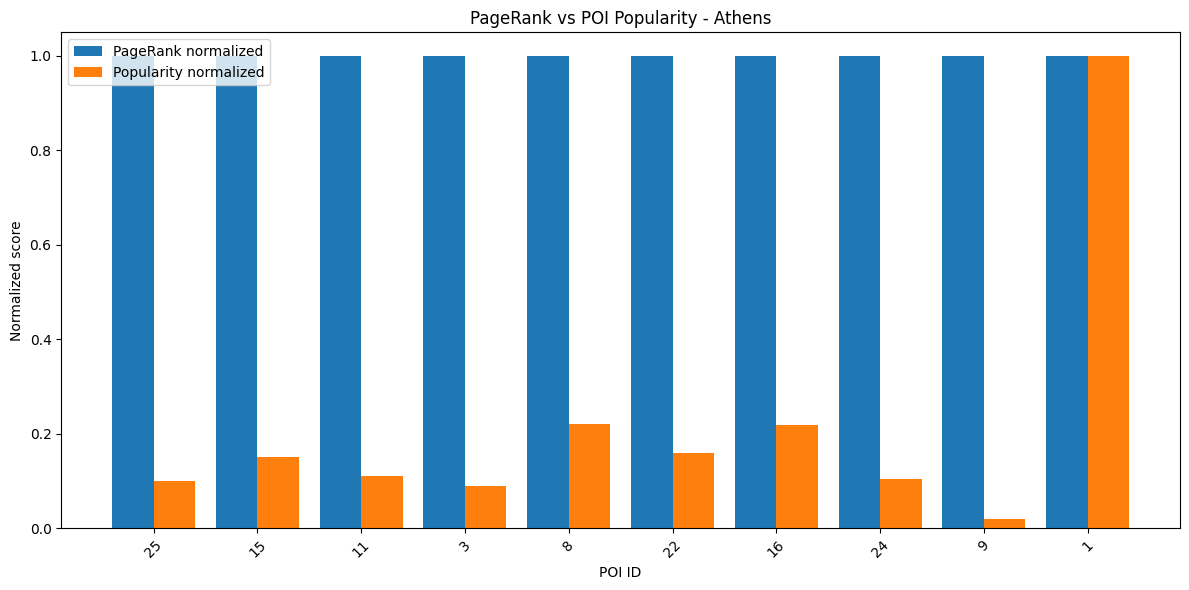

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Athens.png


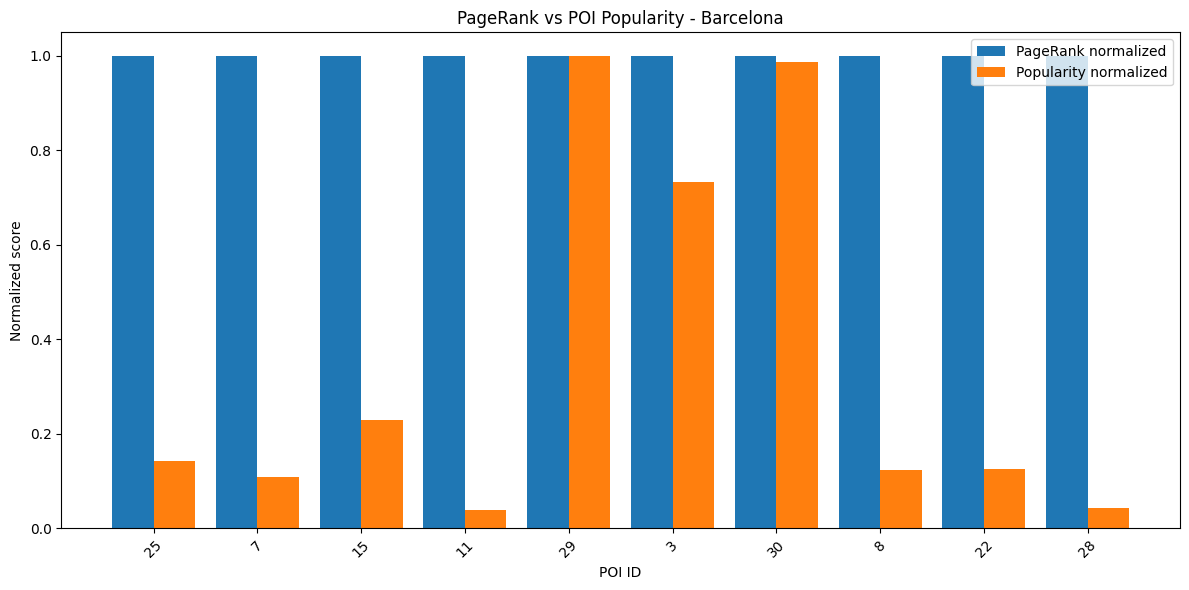

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Barcelona.png


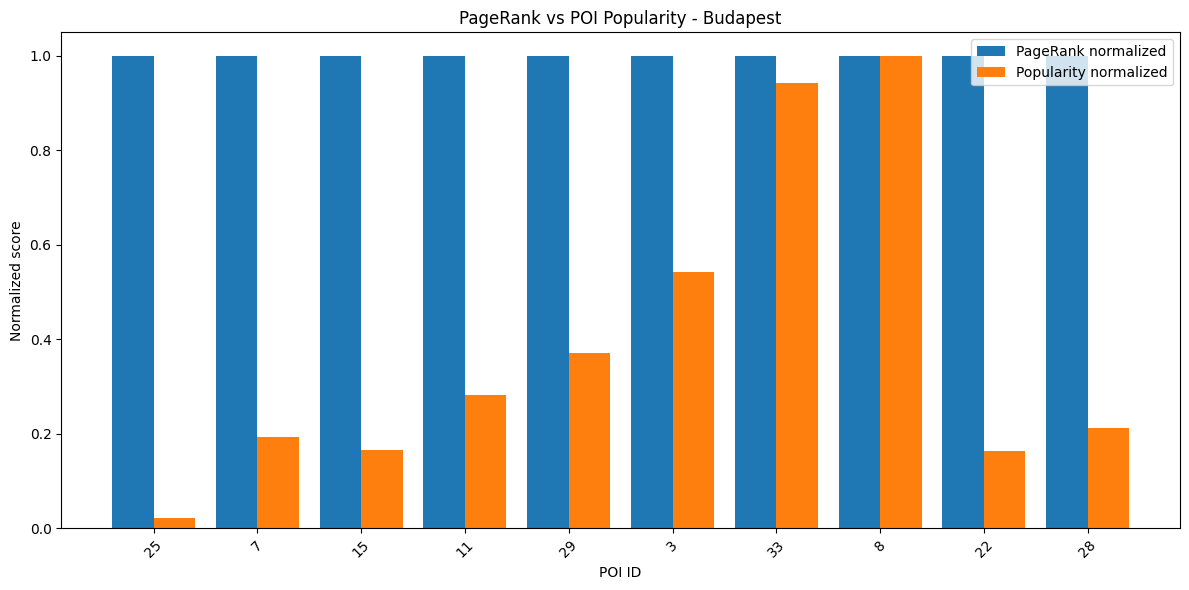

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Budapest.png


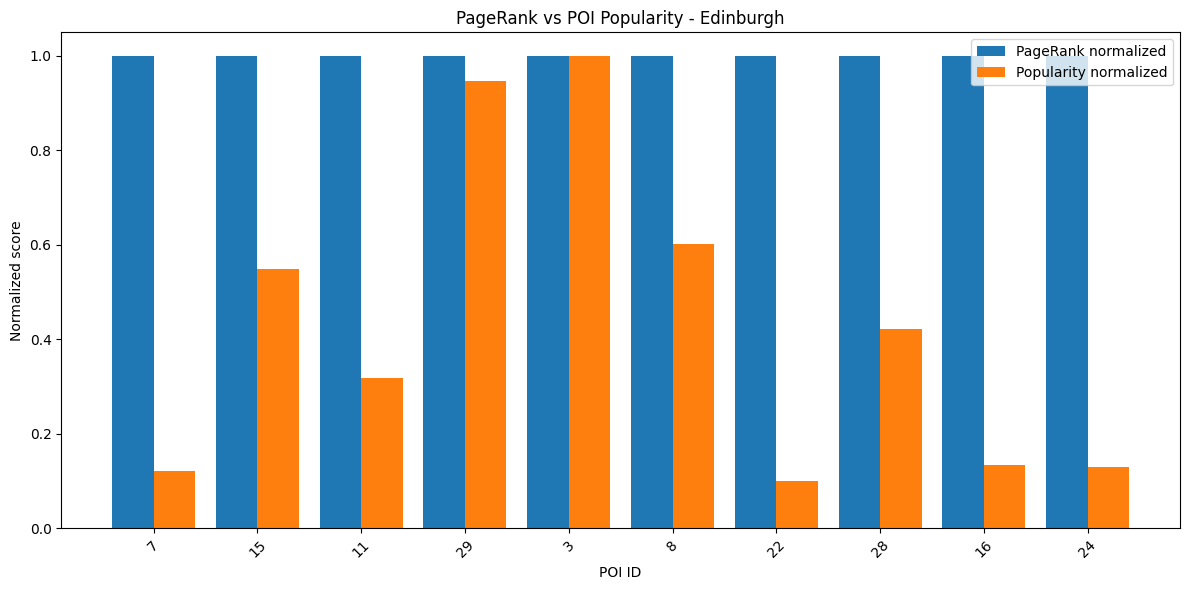

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Edinburgh.png


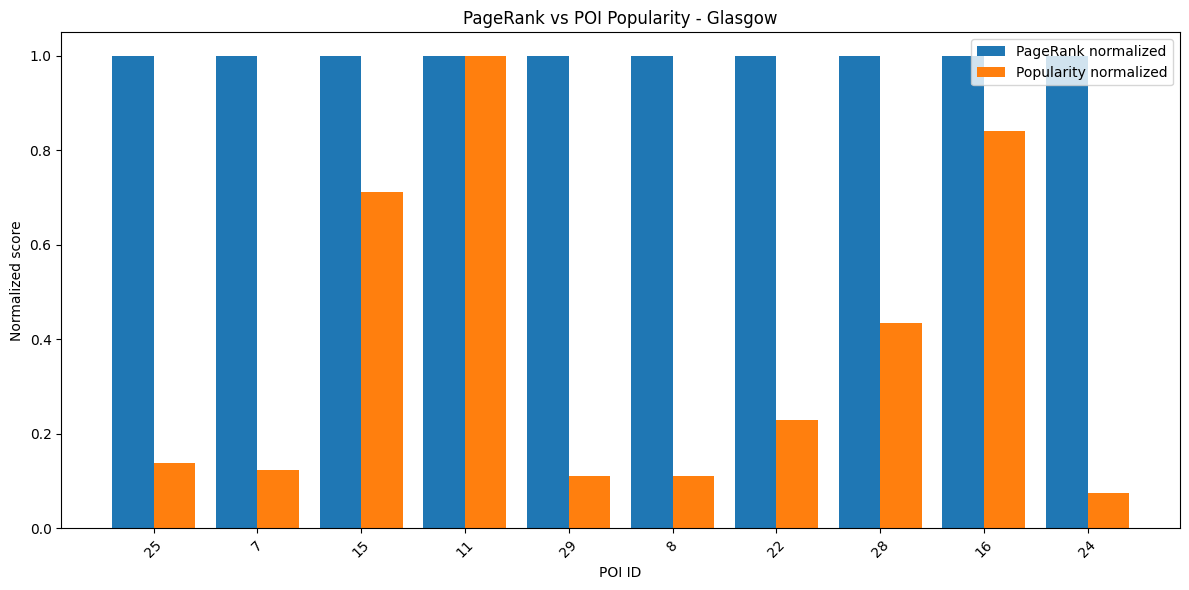

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Glasgow.png


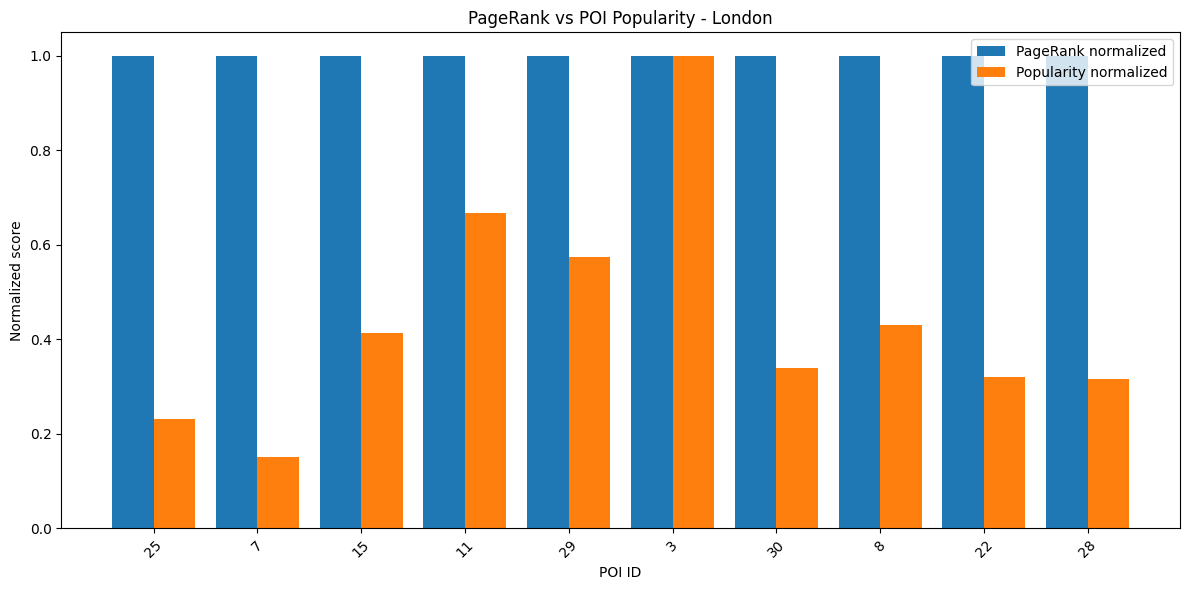

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_London.png


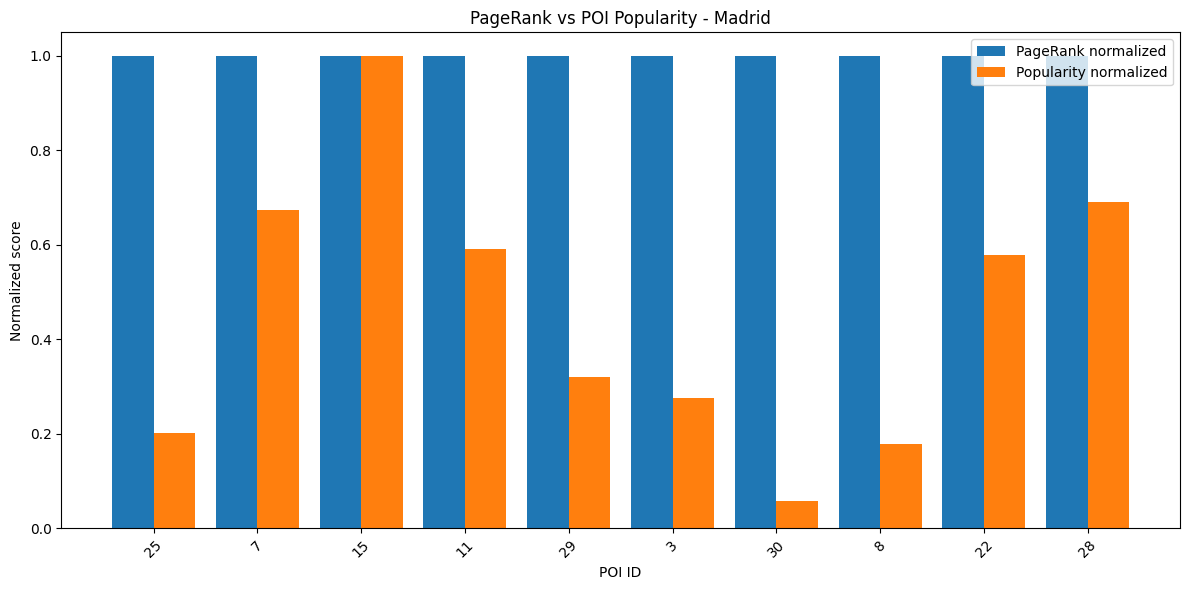

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Madrid.png


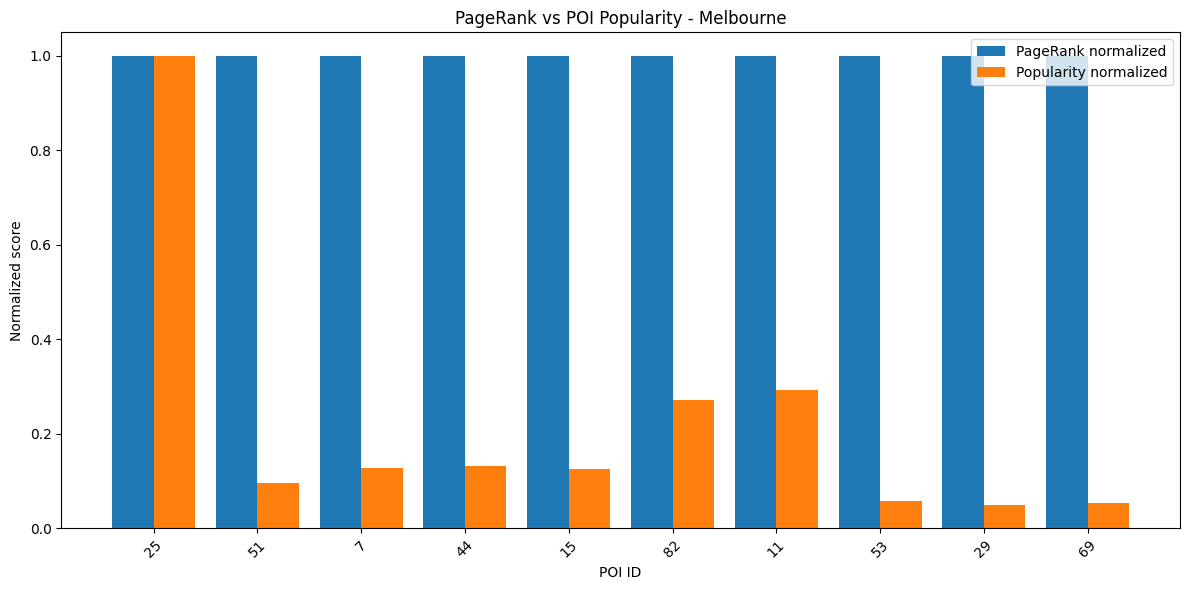

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Melbourne.png


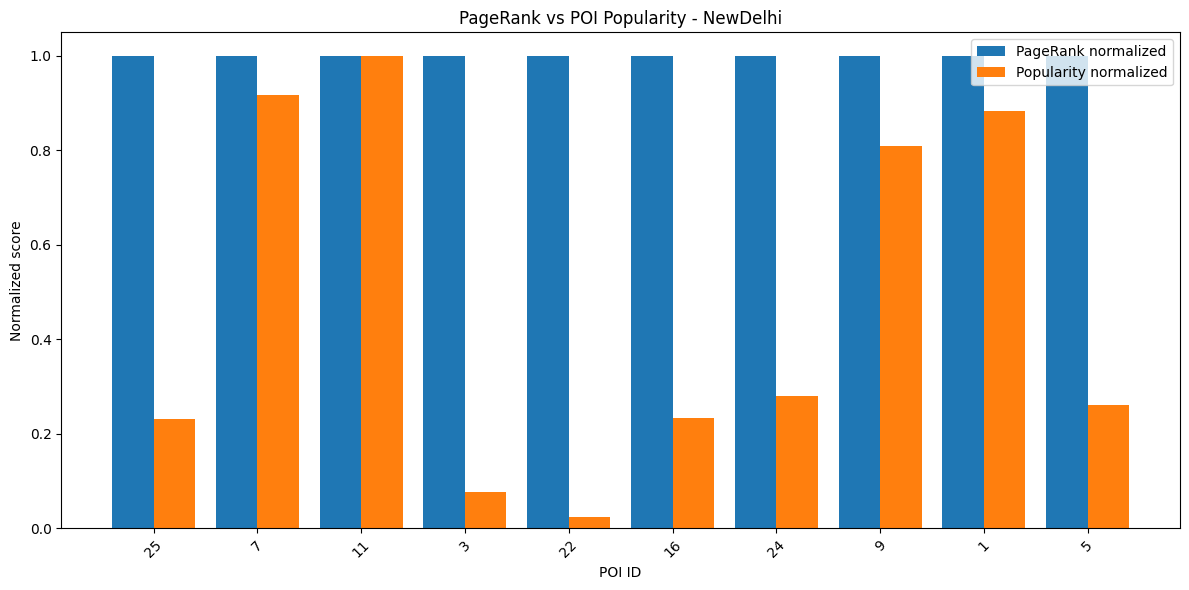

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_NewDelhi.png


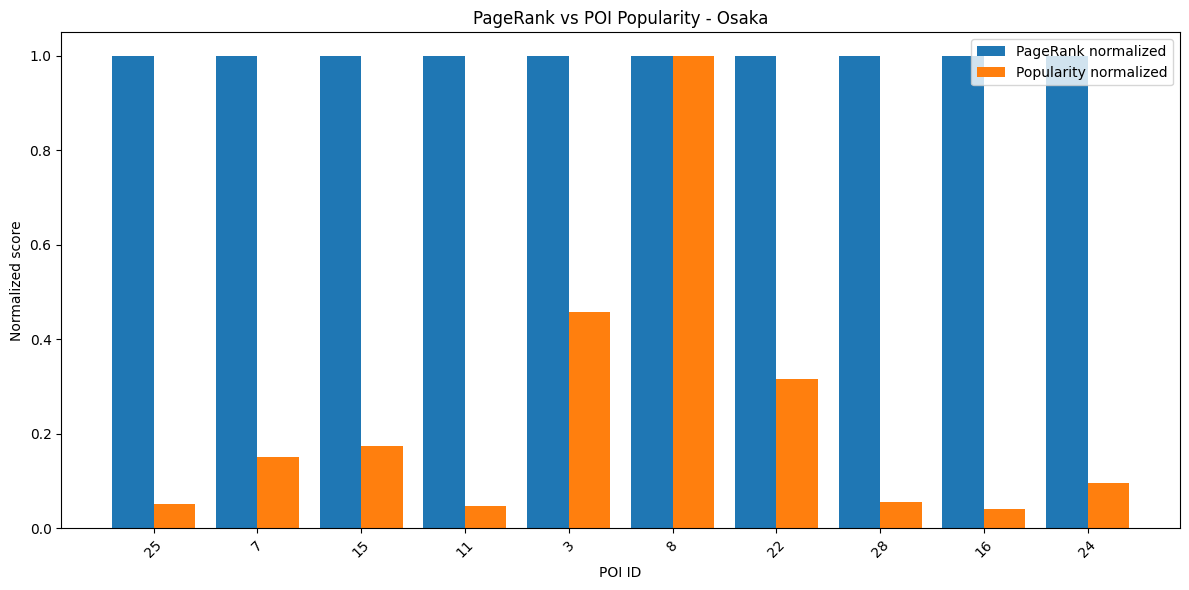

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Osaka.png


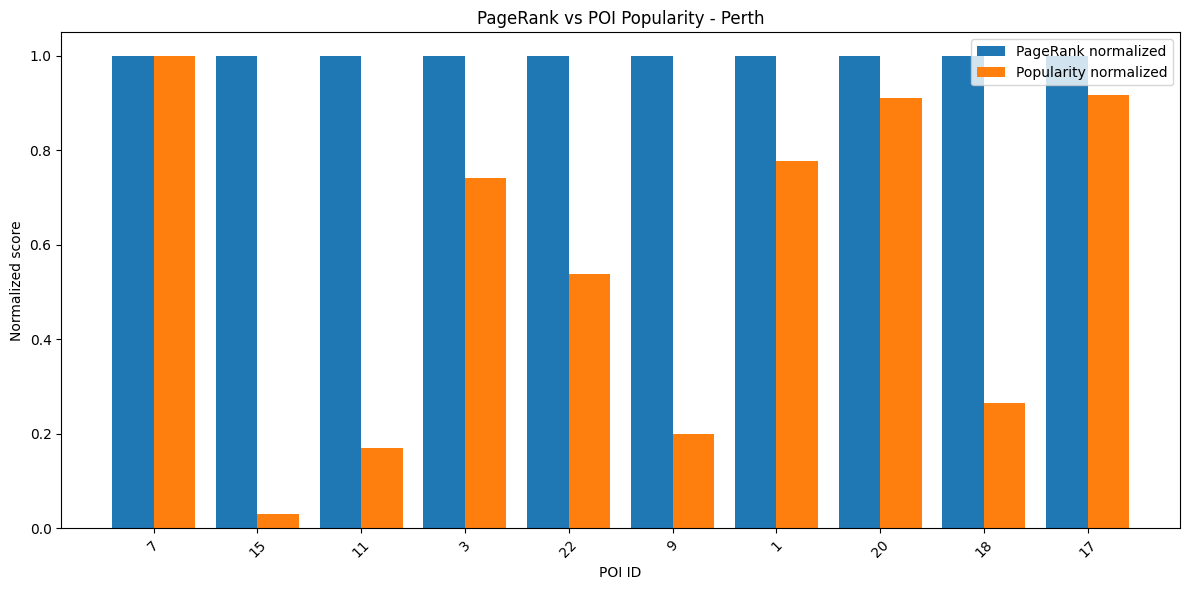

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Perth.png


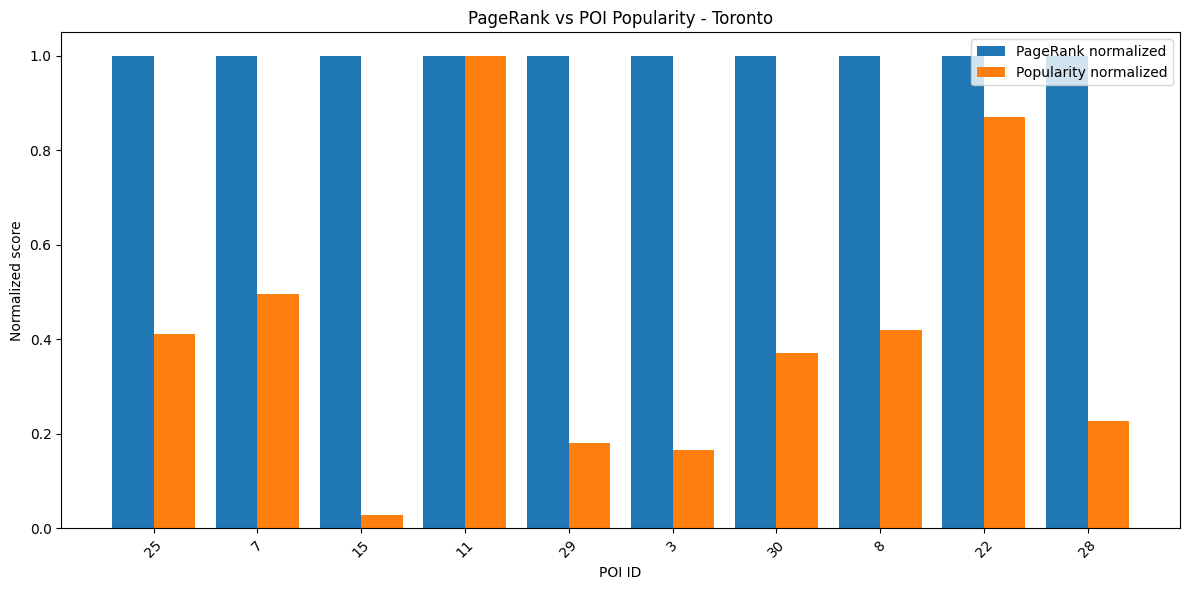

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Toronto.png


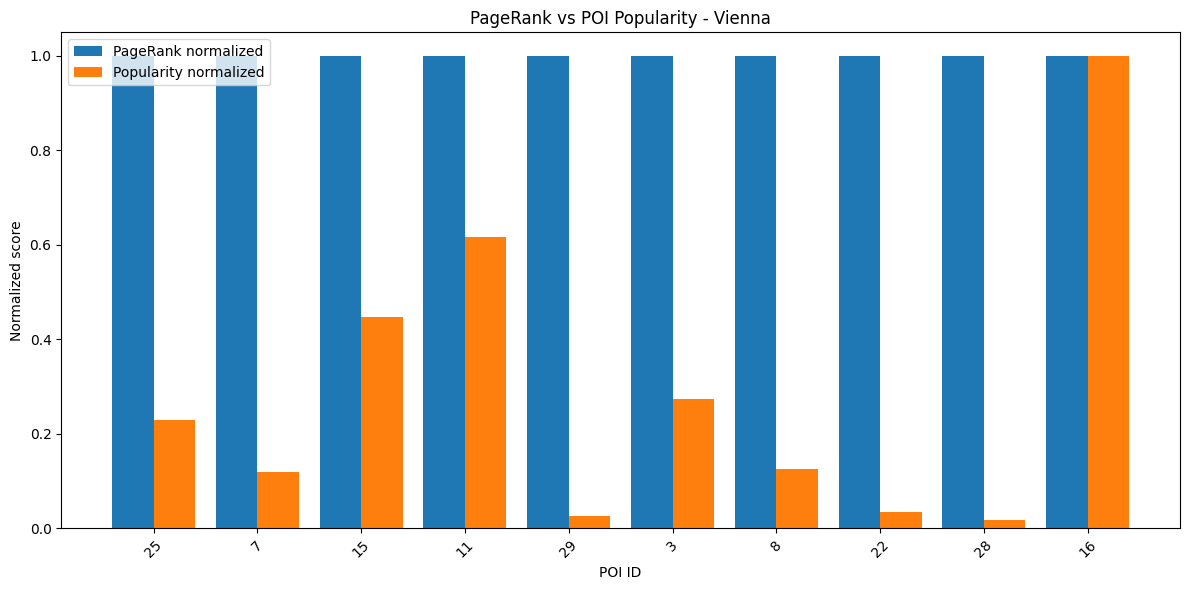

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Vienna.png


[PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Athens.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Barcelona.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Budapest.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Edinburgh.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Glasgow.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_London.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Madrid.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_Melbourne.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_popularity_NewDelhi.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/pagerank_vs_p

In [26]:
import matplotlib.pyplot as plt

saved_files = []

for city in plot_pdf["city"].unique():
    city_pdf = (
        plot_pdf[plot_pdf["city"] == city]
        .sort_values("pagerank_rank")
        .head(10)
    )

    x = list(range(len(city_pdf)))

    plt.figure(figsize=(12, 6))

    plt.bar(
        [i - 0.2 for i in x],
        city_pdf["pagerank_norm"],
        width=0.4,
        label="PageRank normalized"
    )

    plt.bar(
        [i + 0.2 for i in x],
        city_pdf["visit_norm"],
        width=0.4,
        label="Popularity normalized"
    )

    plt.xticks(x, city_pdf["id"], rotation=45)
    plt.xlabel("POI ID")
    plt.ylabel("Normalized score")
    plt.title(f"PageRank vs POI Popularity - {city}")
    plt.legend()
    plt.tight_layout()

    output_path = figure_dir / f"pagerank_vs_popularity_{city}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    saved_files.append(output_path)
    print("Saved:", output_path)

saved_files

## 21. Plot top POIs by popularity

This plot shows the most visited POIs in each city. It can be used as the popularity reference when comparing against PageRank.

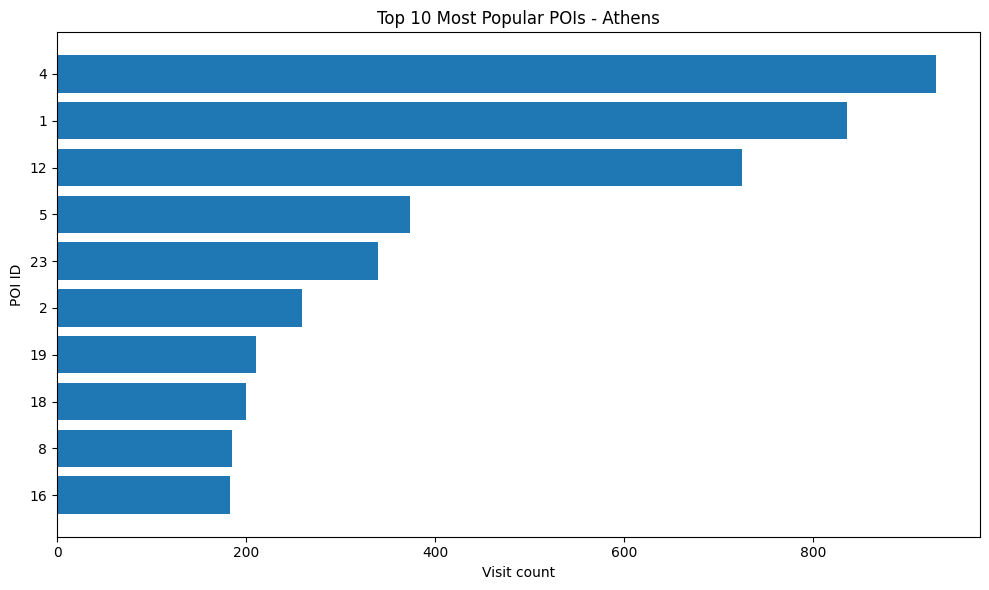

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Athens.png


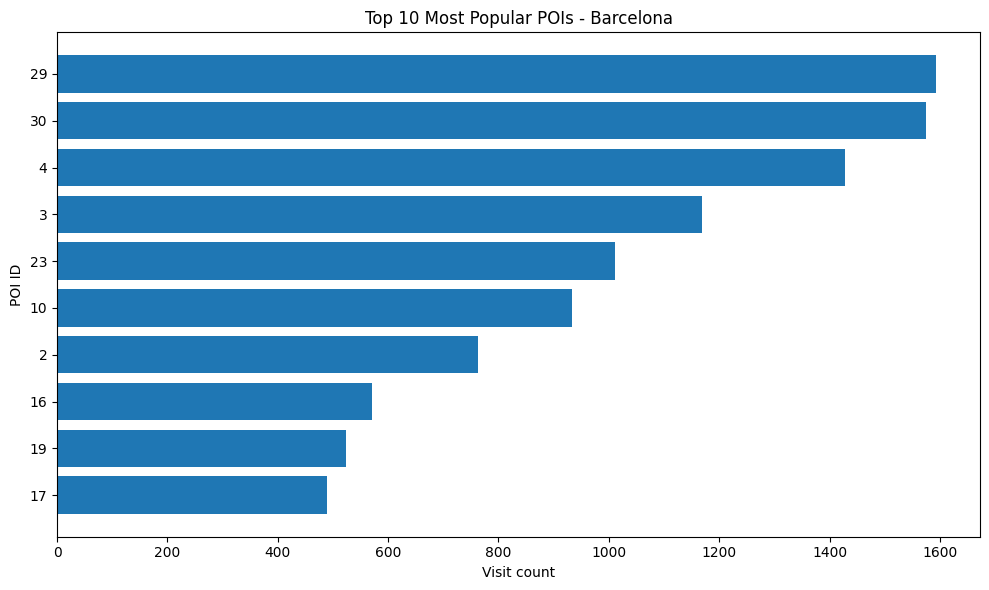

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Barcelona.png


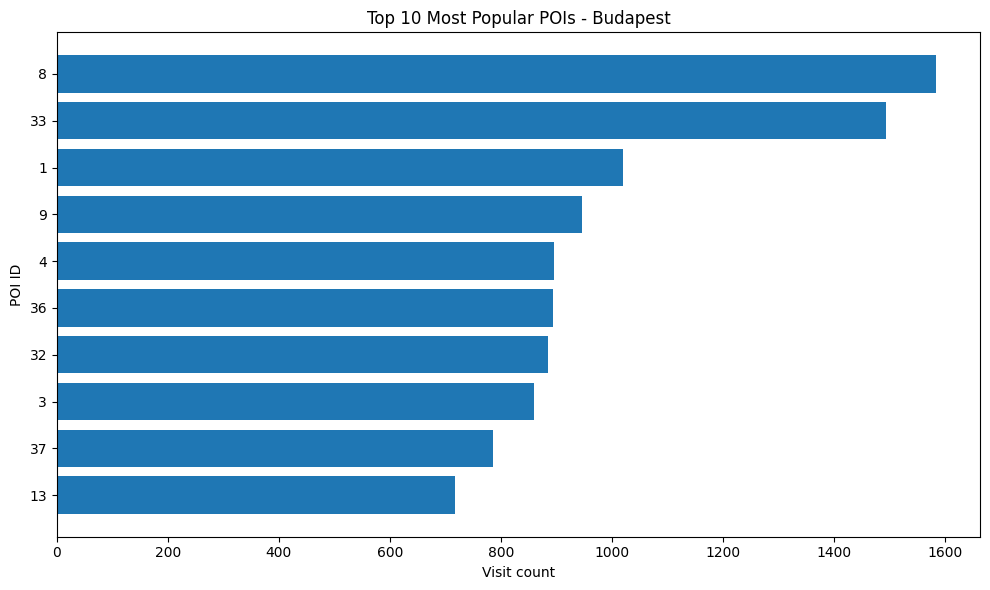

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Budapest.png


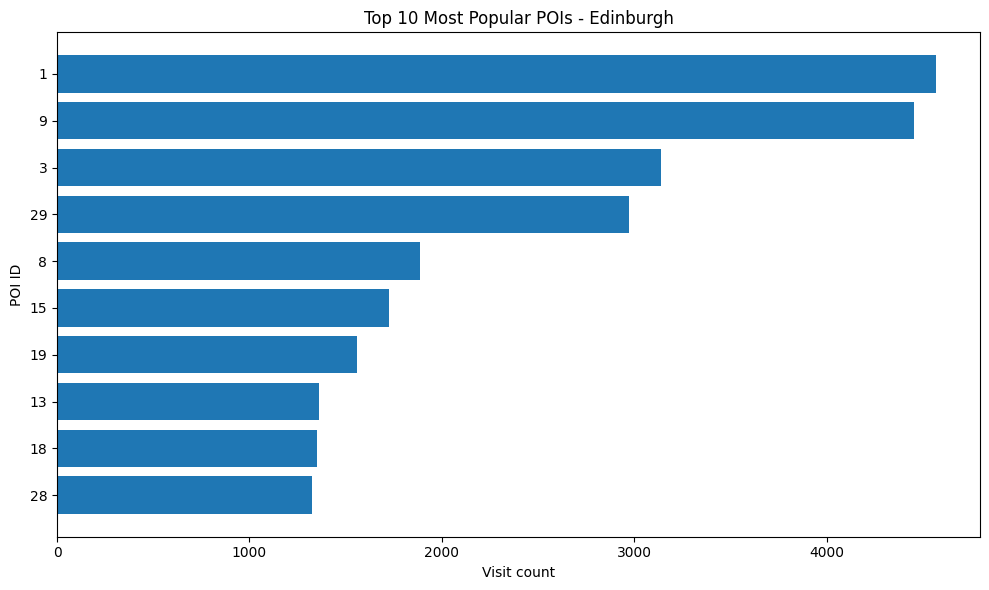

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Edinburgh.png


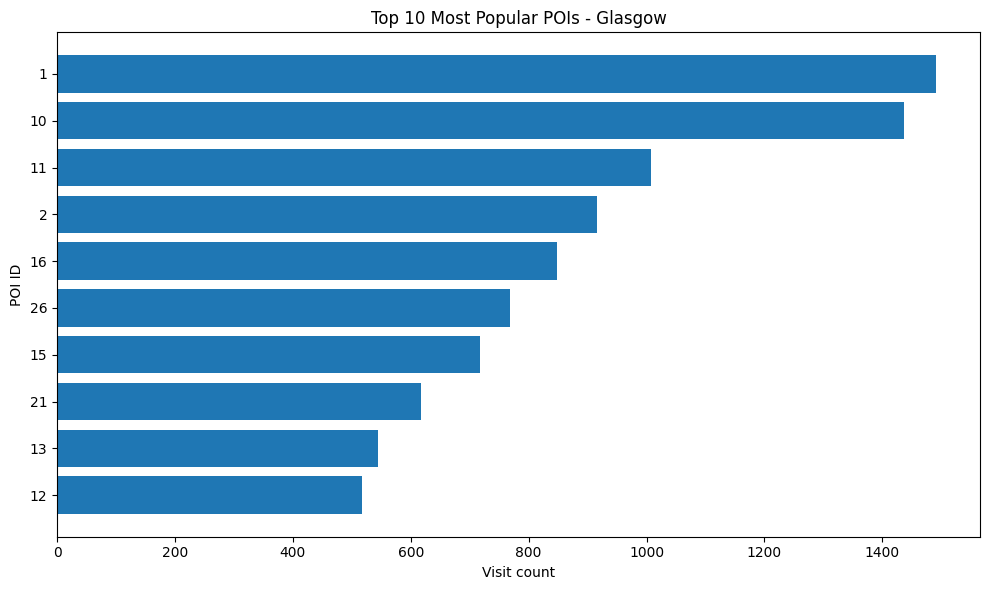

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Glasgow.png


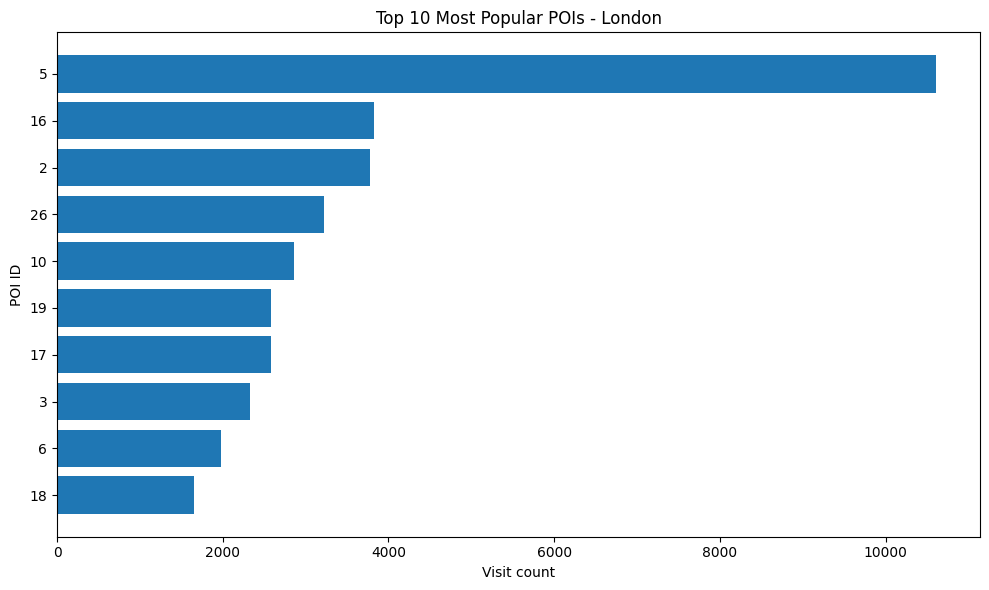

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_London.png


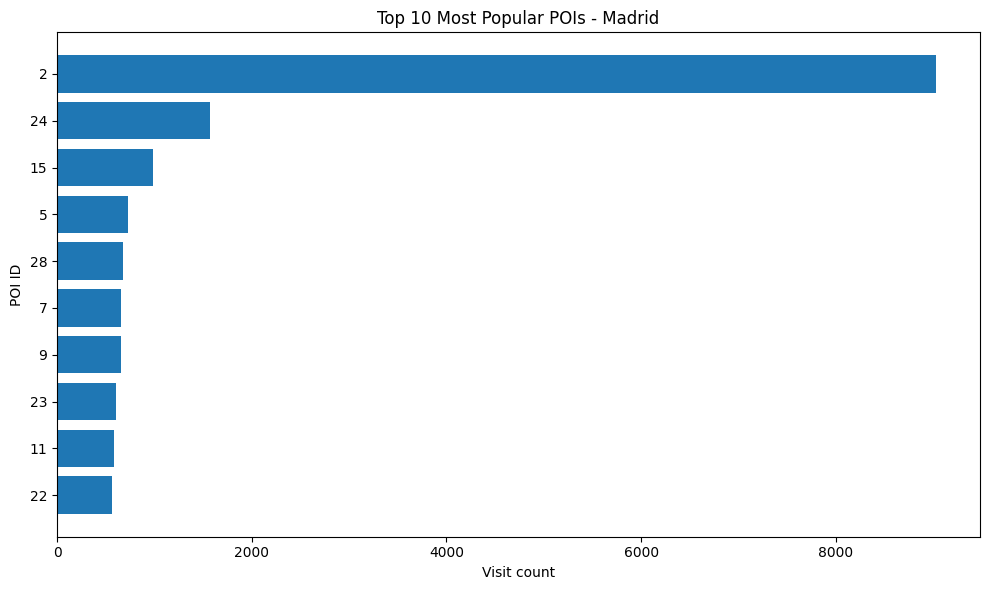

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Madrid.png


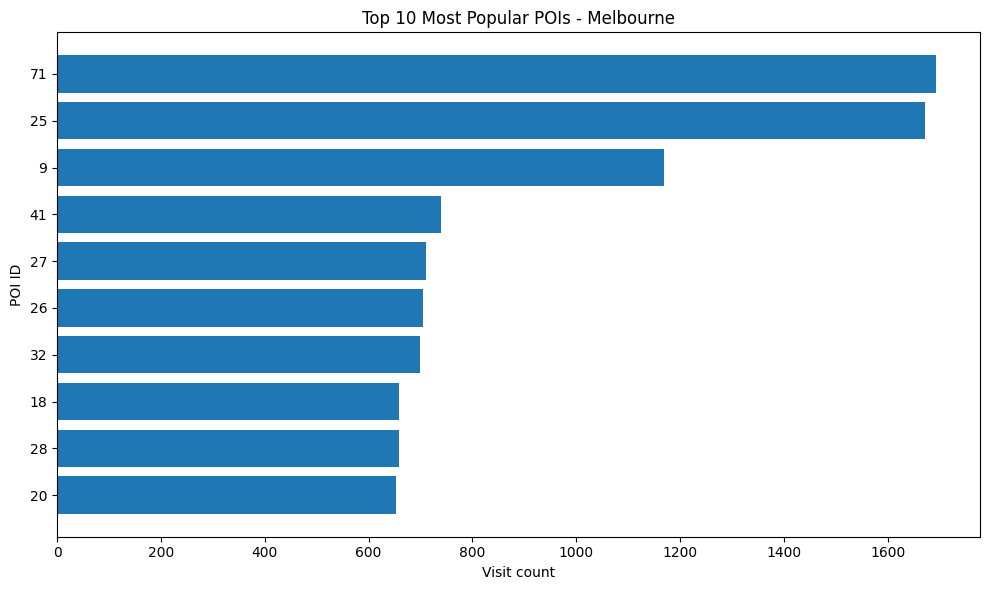

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Melbourne.png


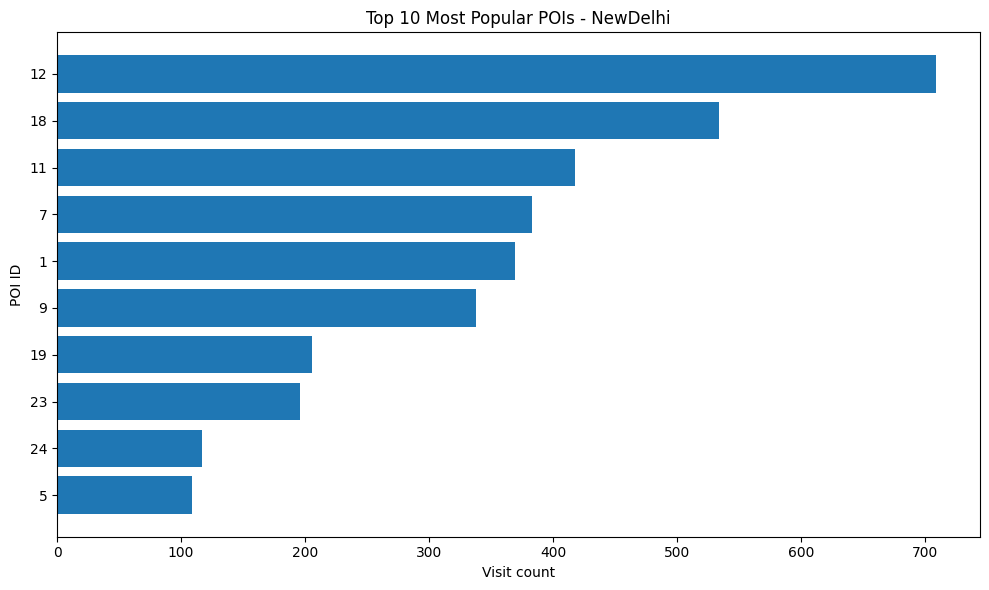

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_NewDelhi.png


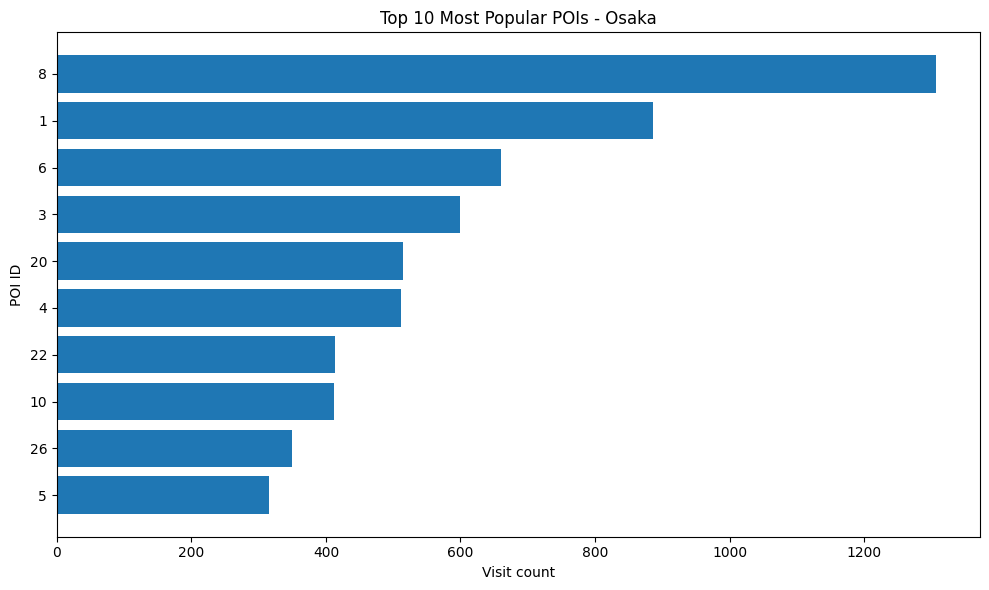

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Osaka.png


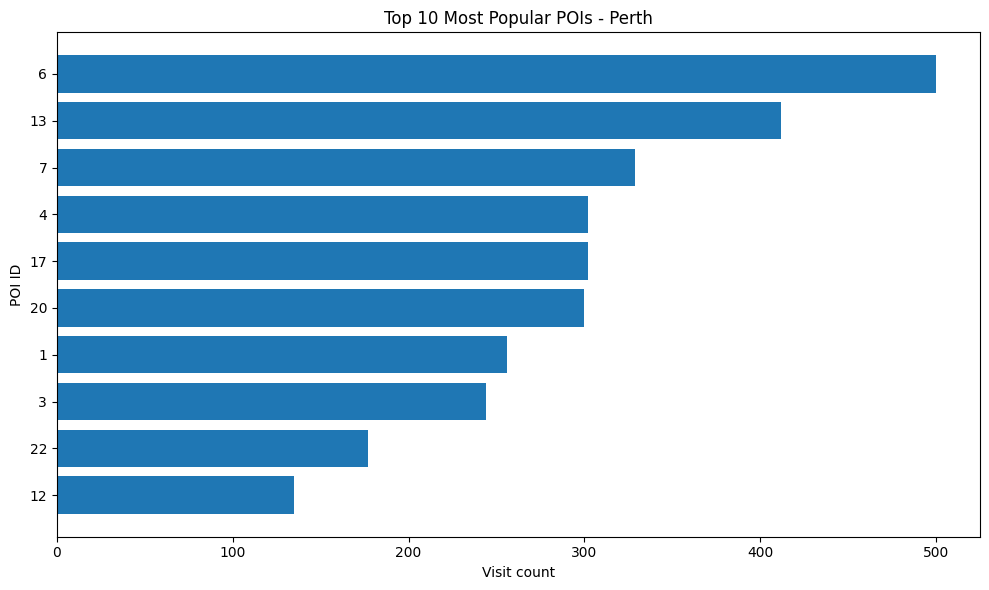

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Perth.png


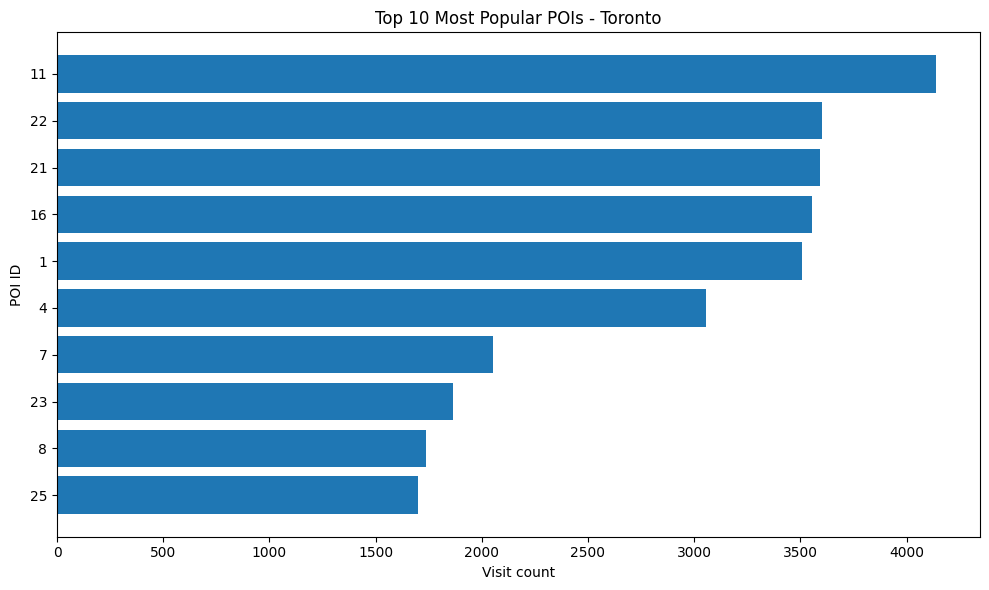

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Toronto.png


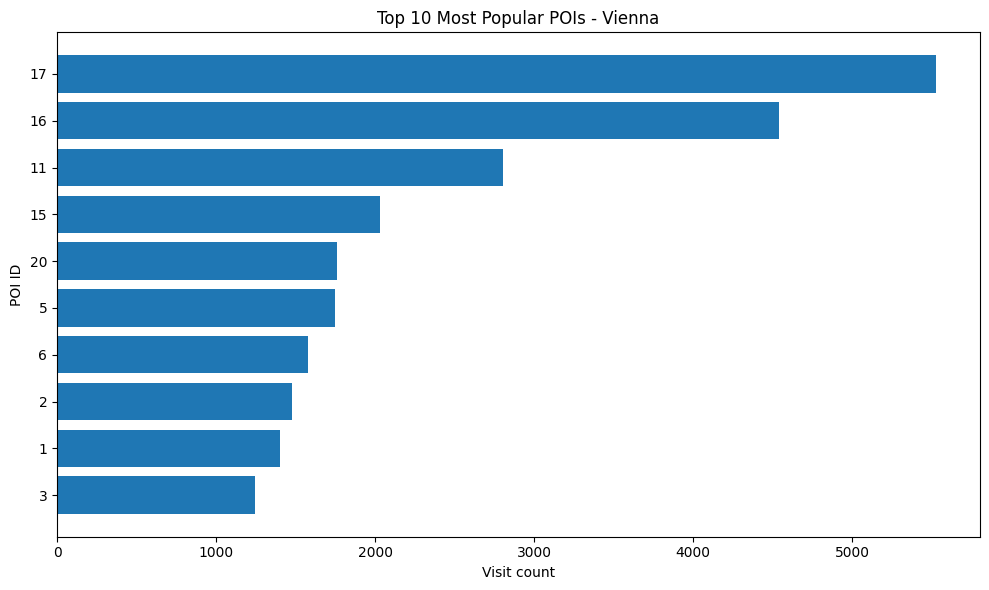

Saved: /home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Vienna.png


[PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Athens.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Barcelona.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Budapest.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Edinburgh.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Glasgow.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_London.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Madrid.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Melbourne.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_NewDelhi.png'),
 PosixPath('/home/cnkdy/projects/smart-tourism/Analysis/figures/top_10_popular_pois_Osaka.png'),
 PosixP

In [27]:
pop_plot_pdf = (
    poi_popularity
    .filter(F.col("popularity_rank") <= 10)
    .toPandas()
)

saved_popularity_files = []

for city in pop_plot_pdf["city"].unique():
    city_pdf = (
        pop_plot_pdf[pop_plot_pdf["city"] == city]
        .sort_values("visit_count", ascending=True)
    )

    plt.figure(figsize=(10, 6))
    plt.barh(city_pdf["id"], city_pdf["visit_count"])
    plt.xlabel("Visit count")
    plt.ylabel("POI ID")
    plt.title(f"Top 10 Most Popular POIs - {city}")
    plt.tight_layout()

    output_path = figure_dir / f"top_10_popular_pois_{city}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    saved_popularity_files.append(output_path)
    print("Saved:", output_path)

saved_popularity_files

## 22. Report-ready summary

The results from this notebook can be summarized as follows:

- PageRank evaluates the structural importance of POIs in the travel network.
- POI popularity evaluates the number of actual tourist visits.
- BFS returns a specific path between two POIs based on the fewest number of edges.
- ShortestPaths returns hop distance from many POIs to selected landmark POIs.
- Weighted shortest path uses the distance matrix to find the actual shortest route by travel distance.
- The saved figures can be used directly in the report or presentation.

## 23. Report paragraph: PageRank versus POI popularity

PageRank and POI popularity measure different aspects of tourism importance. POI popularity is calculated from tourist visit records, so it reflects how frequently each location was visited in the dataset. In contrast, PageRank is calculated from the POI travel network, where each POI is treated as a vertex and travel connections are treated as edges. Therefore, PageRank reflects the structural importance of a POI in the overall route network.

The comparison shows that a highly visited POI is not always the most central POI in the graph. Some POIs may have high popularity because tourists directly prefer them, while others may have high PageRank because they are well connected to many important POIs. These structurally important POIs can support itinerary planning because they may act as useful connection points in a tourism route.

Combining both metrics gives a more complete view for smart tourism analysis. Popularity captures tourist behavior, while PageRank captures network connectivity. A recommendation system can benefit from both indicators by suggesting POIs that are attractive to tourists and also efficient within the travel network.